# Group extraction sweep analysis

Loads every JSON produced by `experiment_maker.py` under `output/group_ext/` and plots:
1. Average extraction (probability-weighted expected value per sample) vs. group extraction
2. Share of individualistic extraction (probability mass on choices > 20) vs. group extraction

In [1]:
import glob
import json
import os
import re

import matplotlib.pyplot as plt

project_dir = os.path.dirname(os.getcwd())
group_ext_dir = os.path.join(project_dir, "output", "group_ext")

In [2]:
def expected_extraction(sample: dict) -> float:
    non_null = {int(choice): prob for choice, prob in sample.items() if prob is not None}
    total_prob = sum(non_null.values())
    return sum(choice * prob for choice, prob in non_null.items()) / total_prob


def individualistic_share(sample: dict) -> float:
    non_null = {int(choice): prob for choice, prob in sample.items() if prob is not None}
    total_prob = sum(non_null.values())
    high_prob = sum(prob for choice, prob in non_null.items() if choice > 20)
    return high_prob / total_prob


def load_group_ext_results(group_ext_dir: str) -> list[dict]:
    rows = []
    for path in sorted(glob.glob(os.path.join(group_ext_dir, "*.json"))):
        match = re.search(r"group_ext=(-?\d+)", os.path.basename(path))
        if match is None:
            continue
        group_ext = int(match.group(1))

        with open(path, encoding="utf-8") as f:
            output = json.load(f)

        samples = list(output["cpr"][0].values())

        rows.append({
            "group_ext": group_ext,
            "avg_extraction": sum(expected_extraction(s) for s in samples) / len(samples),
            "individualistic_share": sum(individualistic_share(s) for s in samples) / len(samples),
        })
    return sorted(rows, key=lambda row: row["group_ext"])

In [3]:
rows = load_group_ext_results(group_ext_dir)
group_ext_values = [row["group_ext"] for row in rows]
avg_extractions = [row["avg_extraction"] for row in rows]
individualistic_shares = [row["individualistic_share"] for row in rows]
rows

[{'group_ext': 10,
  'avg_extraction': 12.77207606651471,
  'individualistic_share': 0.18472000853271014},
 {'group_ext': 15,
  'avg_extraction': 12.69371298755169,
  'individualistic_share': 0.18067015999801614},
 {'group_ext': 20,
  'avg_extraction': 10.009336441097352,
  'individualistic_share': 0.0006285309127257204},
 {'group_ext': 25,
  'avg_extraction': 12.294492483149128,
  'individualistic_share': 0.1464199393720081},
 {'group_ext': 30,
  'avg_extraction': 11.1523727705404,
  'individualistic_share': 0.07591240438198808},
 {'group_ext': 35,
  'avg_extraction': 17.363141339541528,
  'individualistic_share': 0.48492513742118126},
 {'group_ext': 40,
  'avg_extraction': 10.274904972940334,
  'individualistic_share': 0.01776000211777159},
 {'group_ext': 45,
  'avg_extraction': 15.42856784323256,
  'individualistic_share': 0.26993573458764397},
 {'group_ext': 50,
  'avg_extraction': 23.72776520391268,
  'individualistic_share': 0.9036383497051197},
 {'group_ext': 55,
  'avg_extracti

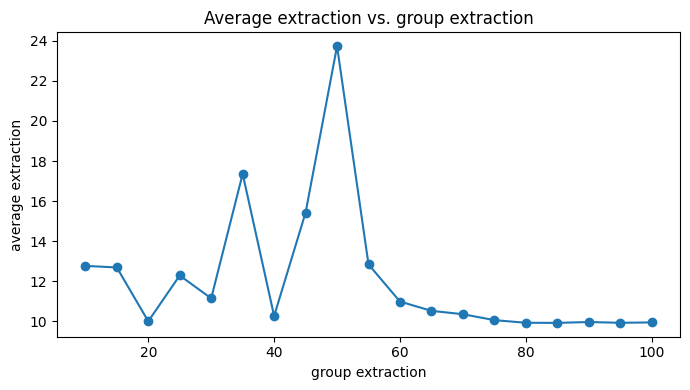

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(group_ext_values, avg_extractions, marker="o")
ax.set_xlabel("group extraction")
ax.set_ylabel("average extraction")
ax.set_title("Average extraction vs. group extraction")
fig.tight_layout()

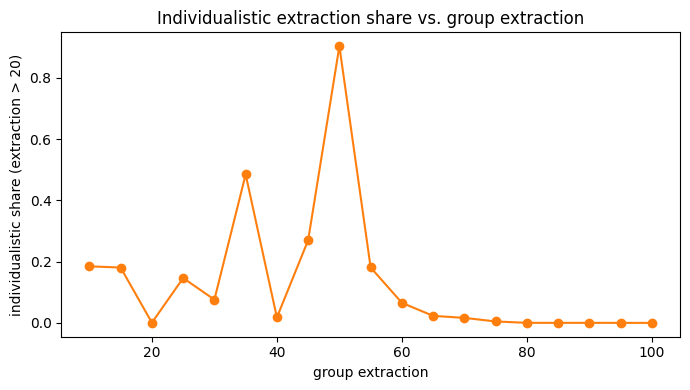

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(group_ext_values, individualistic_shares, marker="o", color="tab:orange")
ax.set_xlabel("group extraction")
ax.set_ylabel("individualistic share (extraction > 20)")
ax.set_title("Individualistic extraction share vs. group extraction")
fig.tight_layout()